In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np
import datetime
import time
import pickle
import os
import seaborn as sns
from scipy.interpolate import make_interp_spline

import sys
sys.path.append("src")

from data_generation import *
from neural_networks import *
from estimation import *

pd.options.mode.chained_assignment = None
os.chdir('Result_Tables/')

## run the simulation

In [2]:
seed_list = [7456]
    
dg_list = [rcl_in3] 
JKM_list = [[2,0,1000]]
delta = 0.1 

hyper_params = {'hidden_size': 256, 'num_hidden_layers': 5, 'n_epochs': 2000, 'learning_rate': 0.0001}

for [J, K, M] in JKM_list:
    for dg in dg_list:
        for i in range(len(seed_list)):
            seed = seed_list[i]
            params = [np.ones(K+2), np.ones(K+2)]
            params[0][-1] = -1
            full_one_iteration(J, M, K, seed, dg, params, hyper_params, delta)
            print(J, K, M, i, 'finished', datetime.datetime.now())
        report(J, K, M, seed_list, dg)

Data is generated.
Main model is trained.
RCL is estimated.
MNL is estimated.
NP is estimated.
Prediction errors are calculated.
Elasticity errors are calculated.
2 0 1000 0 finished 2026-03-09 15:47:42.486751


## Create the plot

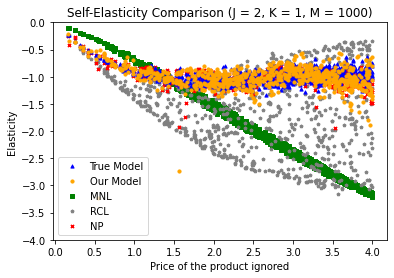

In [3]:
[J, K, M] = [2,0,1000]
dg = rcl_in3
seed_list = [7456]
#os.chdir('Result_Tables/')

elas_all = pd.DataFrame()
for seed in seed_list:
    elas_file = 'elas_record_'+ 'J' + str(J) + 'K' +  str(K) +'M' + str(M) + '_'+str(seed) + str(dg).split()[1] +".csv"
    elas_record = pd.read_csv(elas_file)
    elas_record['seed'] = seed
    elas_all = pd.concat([elas_all, elas_record])

elas_all['ae_deep'] = np.abs(elas_all['error_deep'])
elas_all['ae_mnl'] = np.abs(elas_all['error_mnl'])
elas_all['ae_rcl'] = np.abs(elas_all['error_rcl'])
elas_all['ae_single'] = np.abs(elas_all['error_single'])

# Find the index of the highest value of 'old_price' within each group of ['market_Id', 'i']
max_indices = elas_all.groupby(['market_id', 'i'])['old_price'].idxmax()

# Create a DataFrame containing the ['market_Id', 'i'] and 'j' columns for the max_indices
max_ids = elas_all.loc[max_indices, ['market_id', 'i', 'j']]

# Merge the original DataFrame with the max_ids DataFrame to create a new column 'id_max'
elas_all = elas_all.merge(max_ids, on=['market_id', 'i'], suffixes=('', '_max'))

# Rename the new column to 'id_max'
elas_all.rename(columns={'j_max': 'id_max'}, inplace=True)
elas_all_in = elas_all.loc[elas_all.i == elas_all.id_max].copy()

## create the plot
df = elas_all_in.copy()
fig = plt.figure(figsize=(6, 4))


# Scatter plot for MNL
plt.scatter(df.loc[df.type == 'self']['old_price'], df.loc[df.type == 'self']['pred_elasticity_mnl'],
            marker='s', color='green', label='MNL', s=10)  # square markers

# Scatter plot for RCL
plt.scatter(df.loc[df.type == 'self']['old_price'], df.loc[df.type == 'self']['pred_elasticity_rcl'],
            marker='p', color='grey',label='RCL', s=10)  # pentagon markers

# Scatter plot for NP
plt.scatter(df.loc[df.type == 'self']['old_price'], df.loc[df.type == 'self']['pred_elasticity_single'],
            marker='x', color='red', label='NP', s=10)  # increased size for visibility

# Scatter plot for True Model
plt.scatter(df.loc[df.type == 'self']['old_price'], df.loc[df.type == 'self']['true_elasticity'],
            marker='^', color='blue', label='True Model', s=10)  # triangle_up markers

# Scatter plot for Our Model
plt.scatter(df.loc[df.type == 'self']['old_price'], df.loc[df.type == 'self']['pred_elasticity_deep'],
            marker='o', color='orange', label='Our Model', s=10)  # circle markers

# Add legend, labels, and title

# Add legend, labels, and title
handles, labels = plt.gca().get_legend_handles_labels()
order = [3, 4, 0, 1, 2]  # The desired order
plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order], fontsize=10)

plt.xlabel('Price of the product ignored')
plt.ylabel('Elasticity')
plt.title('Self-Elasticity Comparison (J = 2, K = 1, M = 1000)')
plt.ylim(-4, 0)


# Display the plot
plt.show()


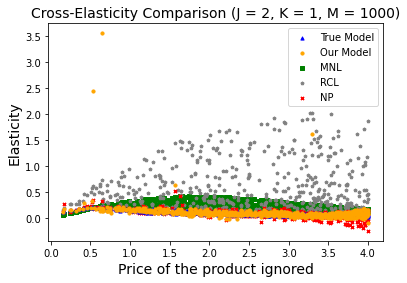

In [4]:
df = elas_all_in.copy()
fig = plt.figure(figsize=(6, 4))

# Scatter plot for MNL
plt.scatter(df.loc[df.type == 'cross']['price_i'], df.loc[df.type == 'cross']['pred_elasticity_mnl'],
            marker='s', color='green', label='MNL', s=10)  # square markers

# Scatter plot for RCL
plt.scatter(df.loc[df.type == 'cross']['price_i'], df.loc[df.type == 'cross']['pred_elasticity_rcl'],
            marker='p', color='grey', label='RCL', s=10)  # pentagon markers

# Scatter plot for NP
plt.scatter(df.loc[df.type == 'cross']['price_i'], df.loc[df.type == 'cross']['pred_elasticity_single'],
            marker='x', color='red', label='NP', s=10)  # increased size for visibility

# Scatter plot for True Model
plt.scatter(df.loc[df.type == 'cross']['price_i'], df.loc[df.type == 'cross']['true_elasticity'],
            marker='^', color='blue', label='True Model', s=10)  # triangle_up markers

# Scatter plot for Our Model
plt.scatter(df.loc[df.type == 'cross']['price_i'], df.loc[df.type == 'cross']['pred_elasticity_deep'],
            marker='o', color='orange', label='Our Model', s=10)  # circle markers

# Add legend, labels, and title
handles, labels = plt.gca().get_legend_handles_labels()
order = [3, 4, 0, 1, 2]  # The desired order
plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order], fontsize=10)

plt.xlabel('Price of the product ignored', fontsize=14)
plt.ylabel('Elasticity', fontsize=14)
plt.title('Cross-Elasticity Comparison (J = 2, K = 1, M = 1000)', fontsize=14)

# Display the plot
plt.show()

fig.savefig('/home/jupyter-colab-project/cross_elas_J2.png', dpi=150)
